In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd

df = pd.read_csv("term-deposit-marketing-2020.csv")
print(df.head())
print(df.info())
print(df.describe())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign   y  
0  unknown    5   may       261         1  no  
1  unknown    5   may       151         1  no  
2  unknown    5   may        76         1  no  
3  unknown    5   may        92         1  no  
4  unknown    5   may       198         1  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2

Decent-sized dataset
Numeric: age, balance, day, duration, campaign	Can be directly used or scaled.
Object/Categorical: job, marital, education, default, housing, loan, contact, month, y	Needs encoding (One-Hot / Target Encoding).
Missing values: None
balance min = -8019, max = 102127	Outliers exist. Some very negative balances → may need transformation or winsorization.
duration min = 0, max = 4918	Some extremely long calls → could affect model. Consider log-transform or cap extremes.
campaign min = 1, max = 63	Some customers contacted 63 times → outliers possible, may skew model.
target y is object ('yes'/'no')	Will need binary encoding: 1 = yes, 0 = no.

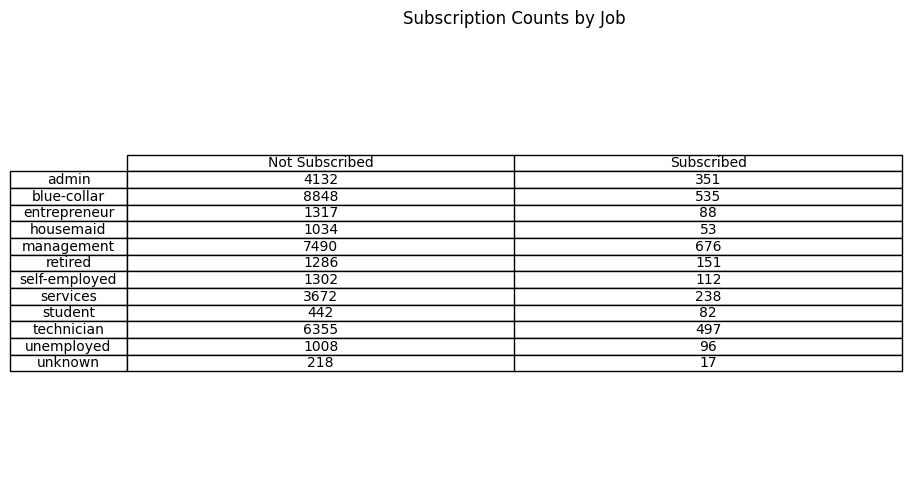

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a counts table for 'job' vs 'y'
job_table = pd.crosstab(df['job'], df['y'])
job_table.columns = ['Not Subscribed', 'Subscribed']

# Display as a table using matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=job_table.values,
         rowLabels=job_table.index,
         colLabels=job_table.columns,
         cellLoc='center',
         rowLoc='center',
         loc='center')

plt.title("Subscription Counts by Job")
plt.show()

<Axes: xlabel='marital', ylabel='count'>

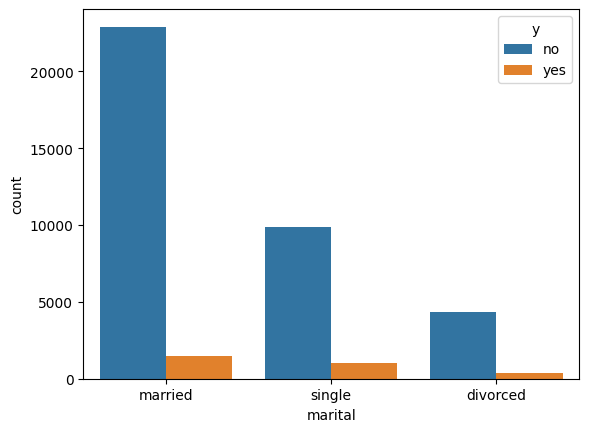

In [4]:

sns.countplot(x='marital', hue='y', data=df)

<Axes: xlabel='education', ylabel='count'>

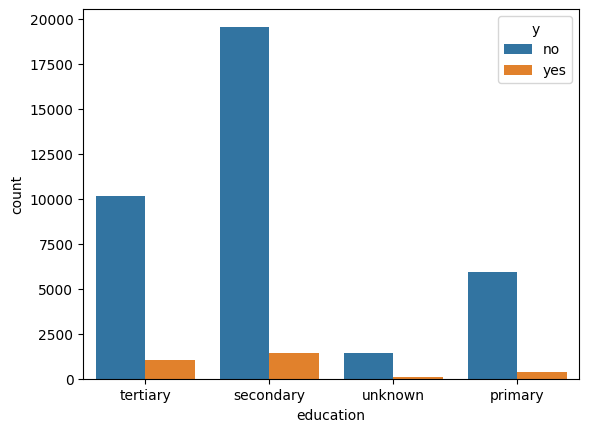

In [5]:
sns.countplot(x='education', hue='y', data=df)

<Axes: xlabel='default', ylabel='count'>

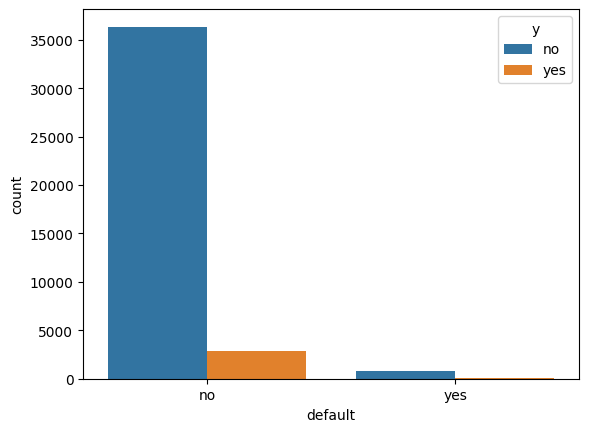

In [6]:

sns.countplot(x='default', hue='y', data=df)

<Axes: xlabel='housing', ylabel='count'>

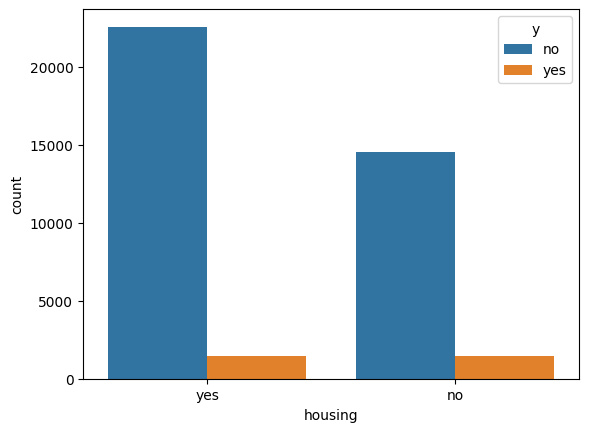

In [7]:

sns.countplot(x='housing', hue='y', data=df)

<Axes: xlabel='loan', ylabel='count'>

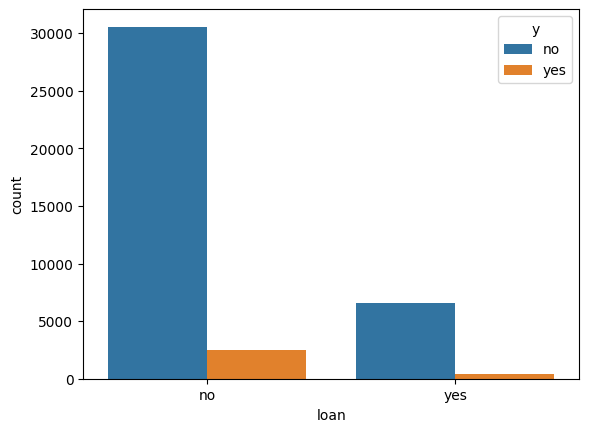

In [8]:

sns.countplot(x='loan', hue='y', data=df)

<Axes: xlabel='contact', ylabel='count'>

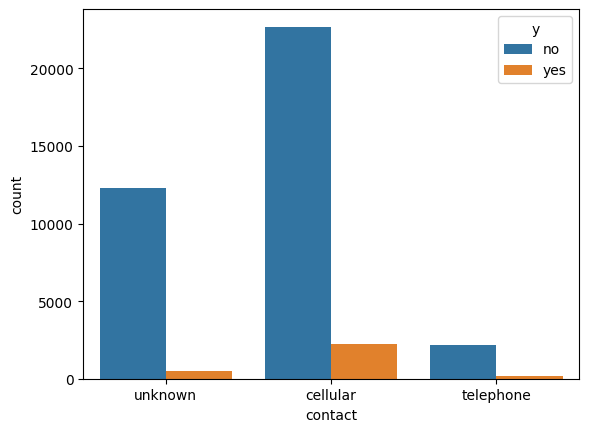

In [9]:

sns.countplot(x='contact', hue='y', data=df)

<Axes: xlabel='month', ylabel='count'>

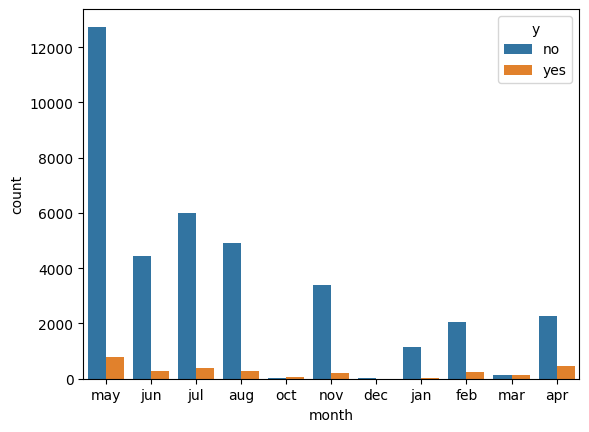

In [10]:

sns.countplot(x='month', hue='y', data=df)

<Axes: xlabel='y', ylabel='age'>

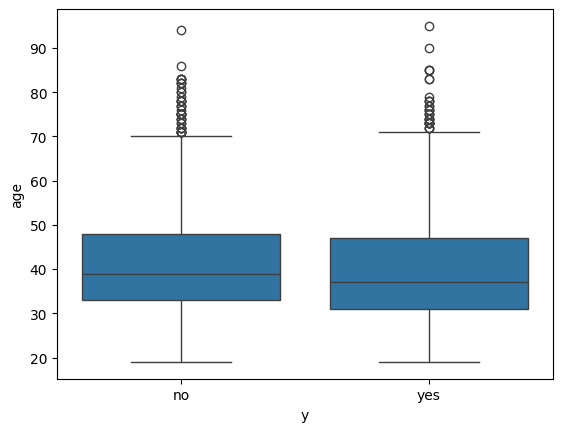

In [11]:
sns.boxplot(x='y', y='age', data=df)

<Axes: xlabel='y', ylabel='balance'>

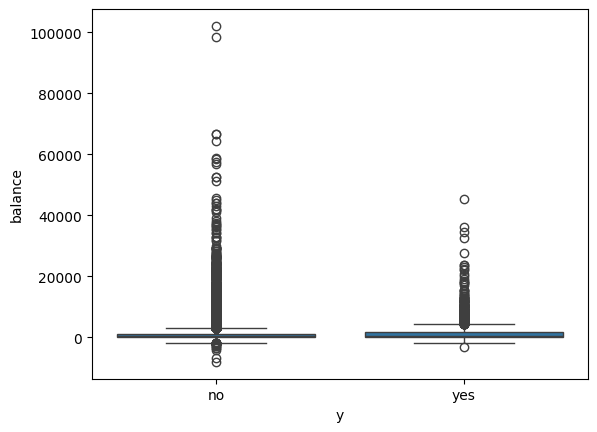

In [12]:

sns.boxplot(x='y', y='balance', data=df)

<Axes: xlabel='y', ylabel='day'>

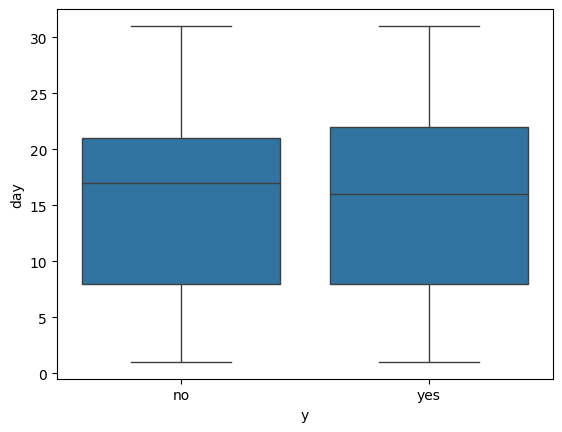

In [13]:

sns.boxplot(x='y', y='day', data=df)

<Axes: xlabel='y', ylabel='campaign'>

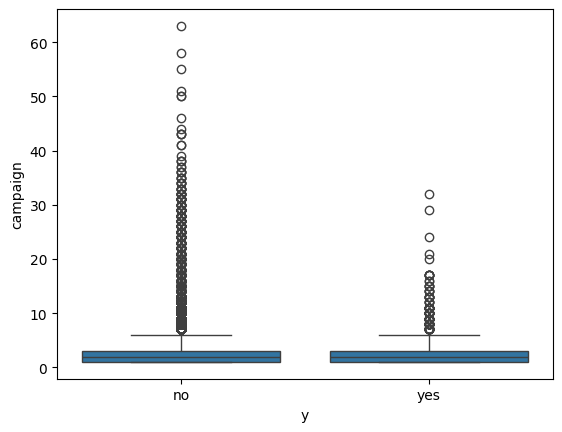

In [14]:

sns.boxplot(x='y', y='campaign', data=df)

In [4]:
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols  # ['age', 'balance', 'day', 'duration', 'campaign', 'y']

corr_matrix = df[numeric_cols].corr()
print(corr_matrix['y'].sort_values(ascending=False))

y           1.000000
duration    0.461169
balance     0.030232
day        -0.006420
age        -0.020273
campaign   -0.040350
Name: y, dtype: float64


Duration has the highest correlation with the target, but it introduces data leakage since it is only known after the call. Therefore, I excluded it from the predictive model while still using it for business insights.

In [6]:
df_model = df.drop(['duration','contact'], axis=1)

In [7]:
X = df.drop(['y','duration','contact'], axis=1)
y = df['y']

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

Train shape: (32000, 11)
Test shape: (8000, 11)
scale_pos_weight: 12.810962451445835


In [14]:
cat_cols = [
    'job','marital','education',
    'default','housing','loan',
    'month'
]

num_cols = [
    'age','balance',
    'day','campaign'
]

preprocessor = ColumnTransformer([
    ('cat',
     OneHotEncoder(handle_unknown='ignore'),
     cat_cols),

    ('num',
     StandardScaler(),
     num_cols)
])

In [15]:
model = Pipeline([
    ('preprocess', preprocessor),

    ('clf',
     XGBClassifier(
         n_estimators=300,
         max_depth=4,
         learning_rate=0.1,
         scale_pos_weight=scale_pos_weight,
         random_state=42,
         eval_metric='logloss'
     ))
])

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy':'accuracy',
    'recall':'recall',
    'f1':'f1',
    'roc_auc':'roc_auc'
}

cv_results = cross_validate(
    model,
    X_train,   # ✅ TRAIN only
    y_train,
    cv=cv,
    scoring=scoring
)

print("\n===== CROSS VALIDATION RESULTS =====")

print("Average CV Accuracy:",
      np.mean(cv_results['test_accuracy']))

print("Average CV Recall:",
      np.mean(cv_results['test_recall']))

print("Average CV F1:",
      np.mean(cv_results['test_f1']))

print("Average CV ROC-AUC:",
      np.mean(cv_results['test_roc_auc']))


===== CROSS VALIDATION RESULTS =====
Average CV Accuracy: 0.77103125
Average CV Recall: 0.4587677813361138
Average CV F1: 0.22484487362801686
Average CV ROC-AUC: 0.6747125934014


In [17]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'balance', 'day',
                                                   'campaign'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               col...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [18]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print("\n===== TEST RESULTS =====")

print("\nClassification Report:\n",
      classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

print("\nTest ROC-AUC:",
      roc_auc_score(y_test, y_prob))
print("Average CV Accuracy:",
      np.mean(cv_results['test_accuracy']))


===== TEST RESULTS =====

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87      7421
           1       0.16      0.50      0.24       579

    accuracy                           0.77      8000
   macro avg       0.56      0.65      0.55      8000
weighted avg       0.90      0.77      0.82      8000


Confusion Matrix:
 [[5910 1511]
 [ 292  287]]

Test ROC-AUC: 0.7041736574008456
Average CV Accuracy: 0.77103125


In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {

    'clf__n_estimators': [200, 300, 400],

    'clf__max_depth': [3, 4, 5],

    'clf__learning_rate': [0.03, 0.05, 0.1],

    'clf__subsample': [0.8, 0.9],

    'clf__colsample_bytree': [0.8, 0.9]

}

In [20]:
random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_dist,

    n_iter=25,   # try 25 models

    scoring='accuracy',  # important (project requires accuracy)

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    verbose=1,

    n_jobs=-1,

    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['job',
                                                                                'marital',
                                                                                'education',
                                                                                'default',
                                                                                'housing',
                                                                                'loan',
                                                                                'month']),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'balance',
                                                                                'day',
                                                                                'campaign'])])),
                                             ('clf',
                                              XGBClassifier(bas...
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=300,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'clf__colsample_bytree': [0.8, 0.9],
                                        'clf__learning_rate': [0.03, 0.05, 0.1],
                                        'clf__max_depth': [3, 4, 5],
                                        'clf__n_estimators': [200, 300, 400],
                                        'clf__subsample': [0.8, 0.9]},
                   random_state=42, scoring='accuracy', verbose=1)

In [21]:
print("Best CV Accuracy:",
      random_search.best_score_)
best_model = random_search.best_estimator_

Best CV Accuracy: 0.81565625


In [22]:
y_pred = best_model.predict(X_test)
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.813125


In [23]:
job_seg = df.groupby('job')['y'].mean()\
            .sort_values(ascending=False)

print(job_seg)

job
student          0.156489
retired          0.105080
unemployed       0.086957
management       0.082782
self-employed    0.079208
admin            0.078296
technician       0.072534
unknown          0.072340
entrepreneur     0.062633
services         0.060870
blue-collar      0.057018
housemaid        0.048758
Name: y, dtype: float64


In [24]:
edu_seg = df.groupby('education')['y'].mean()\
            .sort_values(ascending=False)

print(edu_seg)

education
tertiary     0.091826
secondary    0.067546
unknown      0.062704
primary      0.056300
Name: y, dtype: float64


In [25]:
month_seg = df.groupby('month')['y'].mean()\
              .sort_values(ascending=False)

print(month_seg)

month
oct    0.612500
mar    0.484496
apr    0.165931
feb    0.111063
dec    0.076923
jun    0.062104
nov    0.061145
jul    0.060188
may    0.058454
aug    0.055225
jan    0.032313
Name: y, dtype: float64


In [26]:
print(df.groupby('housing')['y'].mean())

print(df.groupby('loan')['y'].mean())

housing
no     0.089674
yes    0.060921
Name: y, dtype: float64
loan
no     0.076081
yes    0.054834
Name: y, dtype: float64


In [27]:
df['balance_group'] = pd.qcut(
    df['balance'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

print(
    df.groupby('balance_group')['y']
      .mean()
)

balance_group
Low          0.053473
Medium       0.067100
High         0.075800
Very High    0.093247
Name: y, dtype: float64


/tmp/ipykernel_5465/3482782005.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('balance_group')['y']


In [28]:
best_model.fit(X_train, y_train)

importances = best_model.named_steps['clf'].feature_importances_

ohe = best_model.named_steps['preprocess']\
                .named_transformers_['cat']

cat_features = ohe.get_feature_names_out(cat_cols)

features = list(cat_features) + num_cols

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df.head(15))

            feature  importance
32        month_mar    0.112103
35        month_oct    0.076683
25        month_apr    0.057712
28        month_feb    0.039176
13  marital_married    0.036916
21       housing_no    0.034668
22      housing_yes    0.026914
31        month_jun    0.025430
38              day    0.024401
33        month_may    0.024078
26        month_aug    0.023660
34        month_nov    0.023204
23          loan_no    0.021597
29        month_jan    0.021432
37          balance    0.021322


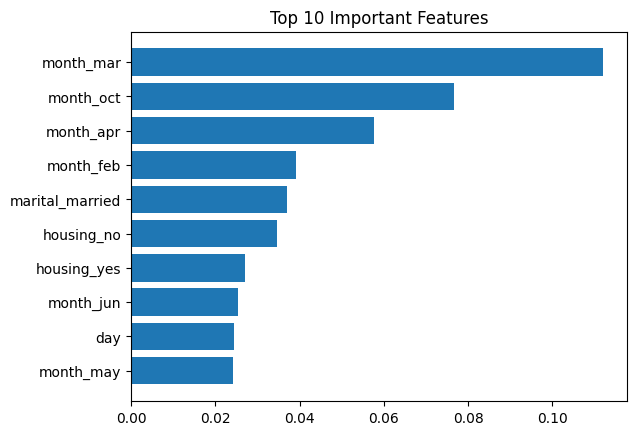

In [29]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure()

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()